<a href="https://colab.research.google.com/github/GermanAlmanza14/Econometria_con_Python/blob/main/mlb1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### License: Creative Commons Attribution 4.0 International (CC BY 4.0)
This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).
<br>
© 2025 Germán Almanza ralmanza@uacj.mx



# **Prueba de restricción lineal multiple: estadístico-F**

Comenzamos instalando el paquete ```wooldridge``` en Colab, esto lo tenemos que hacer cada vez que trabajamos con datos del Wooldridge.

In [ ]:
!pip install wooldridge

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 20.2 MB/s eta 0:00:00


## **Base de datos: mlb1.csv**

Estos datos corresponden a la **Major League Baseball 1993**. [Michael Lewis](https://en.wikipedia.org/wiki/Michael_Lewis) escribió (2003) el libro [Moneyball: The Art of Winning an Unfair Game](https://en.wikipedia.org/wiki/Moneyball:_The_Art_of_Winning_an_Unfair_Game), donde expone que la mayor parte de estrategias del juego se basan en **estadísticas** de los equipos y de los jugadores. En septiembre del 2011, se estrenó la pelicula dirigida por 	Bennett Miller.

<br>

“Las estadísticas no solo eran insuficientes; mentían. Y las mentiras que contaban llevaron a quienes dirigían los equipos de las Grandes Ligas de Béisbol a juzgar mal a sus jugadores y a gestionar mal los partidos.”

― Michael Lewis, en **Moneyball: The Art of Winning an Unfair Game**





<br>

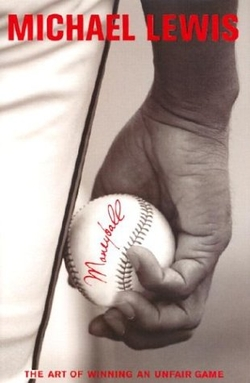 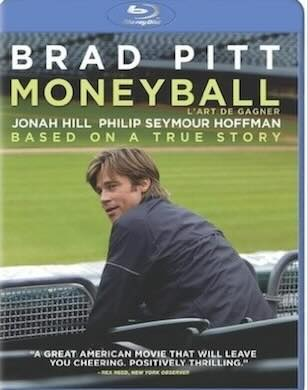


<br>
«Cuando los números adquieren el significado del lenguaje», escribió más tarde, «adquieren el poder de hacer todo lo que el lenguaje puede hacer: convertirse en ficción, drama y poesía… Y no es solo béisbol lo que estos números, a través de un espejo roto, describen. Es carácter. Es psicología, es historia, es poder, es gracia, gloria, constancia, sacrificio, coraje, es éxito y fracaso, es frustración y mala suerte, es ambición, es extralimitación, es disciplina. Y es victoria y derrota, que es todo lo que el subconsciente idiota realmente entiende».

<br>

 Michael Lewis, en **Moneyball: The Art of Winning an Unfair Game**

<br>


In [ ]:
import wooldridge as woo
import numpy as np
import statsmodels.formula.api as smf
import scipy.stats as stats

mlb1 = woo.dataWoo('mlb1')
mlb1

,salary,teamsal,nl,years,games,atbats,runs,hits,doubles,triples,...,runsyr,percwhte,percblck,perchisp,blckpb,hispph,whtepw,blckph,hisppb,lsalary
0,6329213.0,38407380.0,1,12,1705,6705,1076,1939,320,67,...,89.666664,70.277969,18.844229,10.877804,0.000000,0.000000,70.277969,0.000000,0.000000,15.660686
1,3375000.0,38407380.0,1,8,918,3333,407,863,156,38,...,50.875000,70.277969,18.844229,10.877804,18.844229,0.000000,0.000000,10.877804,0.000000,15.031906
2,3100000.0,38407380.0,1,5,751,2807,370,840,148,18,...,74.000000,70.277969,18.844229,10.877804,0.000000,0.000000,70.277969,0.000000,0.000000,14.946913
3,2900000.0,38407380.0,1,8,1056,3337,405,816,143,18,...,50.625000,70.277969,18.844229,10.877804,0.000000,0.000000,70.277969,0.000000,0.000000,14.880221
4,1650000.0,38407380.0,1,12,1196,3603,437,928,19,16,...,36.416668,70.277969,18.844229,10.877804,18.844229,0.000000,0.000000,10.877804,0.000000,14.316286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348,312000.0,35586456.0,0,5,439,1098,150,260,41,8,...,30.000000,73.149635,13.871621,12.978746,0.000000,0.000000,73.149635,0.000000,0.000000,12.650759
349,275000.0,35586456.0,0,2,211,700,63,183,32,1,...,31.500000,73.149635,13.871621,12.978746,0.000000,12.978746,0.000000,0.000000,13.871621,12.524527
350,250000.0,35586456.0,0,3,249,828,112,176,36,2,...,37.333332,73.149635,13.871621,12.978746,0.000000,0.000000,73.149635,0.000000,0.000000,12.429216
351,200000.0,35586456.0,0,6,667,2087,217,510,92,5,...,36.166668,73.149635,13.871621,12.978746,0.000000,0.000000,73.149635,0.000000,0.000000,12.206073


# **Regresión 1 (modelo NO restringido)**

<br>

En el siguiente ejemplo buscamos el impacto que tienen los estadísticos de Beisball en el salario de sus jugadores. Las variables como *salary* y *years* son básicas para ajustar el salario de un jugador; sin embargo, los estadísticos de rendimiento de un jugador (*bavg*, *hrunsyr* y *rbisyr*) son determinantes para su contratación.



**Variables:**

* *salary*: Salario total durante la temporada 1993,
* *years*: Años jugando en ligas mayores,

* *gamesyr*: Promedio de partidos jugados al año,

* *bavg*: Promedio de bateo en la carrera del jugador,

* *hrunsyr*: Cuadrangulares (*homerun*) por año,

* *rbisyr*:  carreras impulsadas por año.

<br>

**Modelo**

$$\log(salary)=\beta_0+\beta_1\; years+\beta_2\; gamesyr+\beta_3\; bavg+\beta_4\; hrunsyr+\beta_5\;  rbisyr+u$$

<br>

El modelo anterior pretende describir el impacto de estas variables en el salario de los jugadores.

<br>


In [ ]:
# regresion OLS: no-restringida
reg_nr = smf.ols(
    formula='np.log(salary) ~ years + gamesyr + bavg + hrunsyr + rbisyr',
    data=mlb1).fit()
reg_nr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         np.log(salary)   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     117.1
Date:                Tue, 05 May 2026   Prob (F-statistic):           2.94e-72
Time:                        19:16:30   Log-Likelihood:                -385.11
No. Observations:                 353   AIC:                             782.2
Df Residuals:                     347   BIC:                             805.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.1924      0.289     38.752      0.000      10.624      11.760
years          0.0689      0.012      5.684      0.000       0.045       0.093
gamesyr        0.0126      0.003      4.742      0.000       0.007       0.018
bavg           0.0010      0.001      0.887      0.376      -0.001       0.003
hrunsyr        0.0144      0.016      0.899      0.369      -0.017       0.046
rbisyr         0.0108      0.007      1.500      0.134      -0.003       0.025
==============================================================================
Omnibus:                        6.816   Durbin-Watson:                   1.265
Prob(Omnibus):                  0.033   Jarque-Bera (JB):               10.197
Skew:                          -0.068   Prob(JB):                      0.00610
Kurtosis:                       3.821   Cond. No.                     2.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### **Resultado de la regresió 1 (modelo NO restringido):**


La regresión muestra que los años jugando en ligas mayores y el promedio de partidos jugados al año, son las variables estadísticamente significativas con un impacto del 6.8% y 1.2% en el salario de los jugadores.  Por otra parte, <mark> los estadísticos de rendimiento (*bavg*, *hrunsyr* y *rbisyr*) resultaron estadísticamente no significativos.</mark>  Sin embargo, estos estadísticos son determinantes en el salario.

<br>

Es posible que los cuadrangulares y las carreras impulsadas por año, esten  **correlacionados**. Si existe una "alta" correlación entre dos variables explicativas se dice que **existe multicolinealidad imperfecta**, en tal caso <mark>la varianza y covarianza de los estimadores es alta, implicando que:</mark>

* las estimaciones sean imprecisas y muy sensibles a pequeños cambios en los datos de la muestra,

* dificulta aislar el efecto individual sobre la variable dependiente.



Significancia individual baja vs. conjunta alta: Es común observar un
 alto y una prueba
 significativa, indicando que el modelo explica bien, mientras que las pruebas
 individuales de los coeficientes no son significativas, dificultando la identificación de qué variables son realmente importantes.


## **Matriz de correlación**


Comenzaremos verificando que las variables no significativas estan correlacionadas; es decir, existe multicolinealidad en la regresión 1 (modelo NO restringido).


En la libreria de `pandas` se encuentra la función `.corr()` que realiza la matriz de **correlación de Pearson** entre las variables. Comenzamos definiendo un subconjunto de `variables` de la base de datos `mlb1` agregada inicialmente.


In [ ]:
variables=mlb1[['years','gamesyr','bavg','hrunsyr','rbisyr']]    #'salary',
corr_var=variables.corr()
corr_var


,years,gamesyr,bavg,hrunsyr,rbisyr
years,1.000000,0.562394,0.197296,0.380162,0.487107
gamesyr,0.562394,1.000000,0.319145,0.613805,0.848658
bavg,0.197296,0.319145,1.000000,0.190596,0.329145
hrunsyr,0.380162,0.613805,0.190596,1.000000,0.890743
rbisyr,0.487107,0.848658,0.329145,0.890743,1.000000


## **Matriz de correlación: seaborn**

La libreria `seaborn` tiene la función `heatmap` que nos permite "visualizar" el nivel de correlación de las variables, poniendo tonos de color más intensos a las variables con mayor correlación.

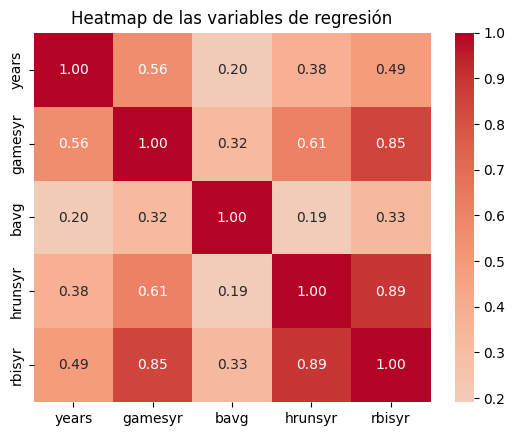

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# heatmap - mapa de calor
sns.heatmap(corr_var,
            annot=True,       # muestra el valor de correlación
            cmap='coolwarm', #  'coolwarm',  # define el color
            fmt=".2f",        # núm de decimales
            center=0)         # asegura que 0 es "color neutro"

plt.title('Heatmap de las variables de regresión')
plt.show()


## **Matriz de correlación: triangular inferior**


Podemos evitar mostrar valores triviales como la diagonal principal y las variables simétricas de la matriz. Para esto introducimos una función de `numpy` llamada `.triu` (triangular upper).

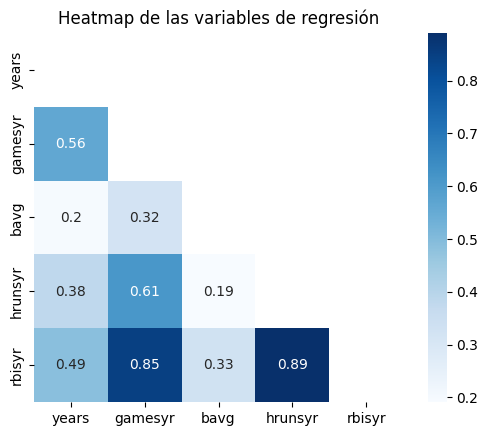

In [ ]:
import numpy as np

mask = np.triu(np.ones_like(corr_var, dtype=bool))
sns.heatmap(corr_var, mask=mask, annot=True, cmap='Blues',square=True)
plt.title('Heatmap de las variables de regresión')
plt.show()

### **Multicolinealidad: variables *hrunyr* - *rbisyr***

La matriz de correlación muestra que las variables *hrunyr*-*rbisyr* y *gamesyr*-*rbisyr* estan fuertemente correlacionadas (0.89 y 0.85, respectivamente). Como hemos dicho previamente, estas varibles son determinantes en la contratación de los jugadores. En este contexto, podemos decir que <mark>la multicolinealidad de las variables genera ineficiencia en los estimadores</mark>. Por lo tanto, vamos a realizar **prubebas de restricción multiple**, también llamadas **pruebas de hipótesis conjunta**.

# **Prueba de hipótesis conjunta: estadístico-F**





Queremos probar que, una vez controladas las variables *years* (años en la liga) y *gamesyr* (partidos por año), los estadísticos que miden el desempeño *bavg*, *hrunsyr* y *rbisyr* no tienen efectos sobre el sueldo. En otras palabras, lo anterior establece que la productividad como la miden las estadísticas de béisbol no tiene efecto sobre el sueldo.

<br>

En realidad este es el planteamiento de la hipótesis nula y esperamos que los datos muestren suficiente evidencia para rechazar esta hipótesis.

<br>

## **Hipótesis múltiple**

Para este proposito, planteamos la siguiente hipótesis

$$H_0:\;\beta_3=\beta_4=\beta_5=0.\qquad(\clubsuit)$$

La ecuación $(\clubsuit)$ se conoce como **restricción múltiple**.
La hipótesis alternativa simplemente es

$$H_1:\;¡H_0\;\text{NO es verdadera!}.\qquad(2\clubsuit)$$

Se satisface $H_1$ si al menos uno de los $\beta_3,\beta_4$ o $\beta_5$ es distinto de cero.


### **Estadísticos del modelo NO restringido**

In [ ]:
#    Estadisticos de interes modelo NO restringido
# R^2
R2_nr=reg_nr.rsquared
print(f"Modelo NO restringido, R-cuadrado: {R2_nr:.4f}")
# Residuales de la reg
residuals_nr=reg_nr.resid
# Suma de los residuales al cuadrado
ssr_nr= np.sum(residuals_nr**2)
print(f"Modelo NO restringido,  SSR: {ssr_nr:.3f}")
#  Grados de libertad
gl_nr=reg_nr.df_resid
print(f"Modelo NO restringido,  gl_nr: {gl_nr:.0f}")


Modelo NO restringido, R-cuadrado: 0.6278
Modelo NO restringido,  SSR: 183.186
Modelo NO restringido,  gl_nr: 347


# **Regresión del modelo restringido**

In [ ]:
# restricted OLS regression:
reg_r = smf.ols(formula='np.log(salary) ~ years + gamesyr', data=mlb1).fit()
reg_r.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         np.log(salary)   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     259.3
Date:                Tue, 05 May 2026   Prob (F-statistic):           8.22e-70
Time:                        19:20:33   Log-Likelihood:                -399.11
No. Observations:                 353   AIC:                             804.2
Df Residuals:                     350   BIC:                             815.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.2238      0.108    103.625      0.000      11.011      11.437
years          0.0713      0.013      5.703      0.000       0.047       0.096
gamesyr        0.0202      0.001     15.023      0.000       0.018       0.023
==============================================================================
Omnibus:                        2.227   Durbin-Watson:                   1.194
Prob(Omnibus):                  0.328   Jarque-Bera (JB):                2.221
Skew:                          -0.032   Prob(JB):                        0.329
Kurtosis:                       3.383   Cond. No.                         263.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### **Estadísticos del modelo restringido**

In [ ]:
#    Estadisticos de interes modelo restringido
# R^2
R2_r=reg_r.rsquared
print(f"Modelo restringido, R-cuadrado: {R2_r:.4f}")
# Residuales de la reg
residuals_r=reg_r.resid
# Suma de los residuales al cuadrado
ssr_r= np.sum(residuals_r**2)
print(f"Modelo restringido,  SSR: {ssr_r:.3f}")
#  Grados de libertad
gl_r=reg_r.df_resid
print(f"Modelo restringido,  gl_r: {gl_r:.0f}")


Modelo restringido, R-cuadrado: 0.5971
Modelo restringido,  SSR: 198.311
Modelo restringido,  gl_r: 350


## **Código del estadístico-F**

In [ ]:
import scipy.stats as sts

#   Diferencia de gl
q=reg_r.df_resid-reg_nr.df_resid
#   Estadistico-F
F_estS=((ssr_r-ssr_nr)/ssr_nr)* (gl_nr/q)

print(f"F= ({ssr_r:.3f}-{ssr_nr:.3f})/({ssr_nr:.3f})*({gl_nr:.0f})/{q:.0f} = {F_estS:.3f}")
print(f'El estadístico F={F_estS:.3f}')

alpha=.99
signif=1-alpha
nu1=q
nu2=gl_nr

F_val=sts.f.ppf(alpha,nu1,nu2)
print(f'Valor crítico o F-value: {F_val:.4f}')

#    Criterio
if F_estS>F_val:
    print('Dado que estadístico-F>F-value, se rechaza H0:')
    print(f'las variables son conjuntamente significativas al {signif:.4}%.')
else:
    print('Dado que estadístico-F<F-value,\n NO se rechaza H0: ¡Las variables son conjuntamente NO significativas!.')


F= (198.311-183.186)/(183.186)*(347)/3 = 9.550
El estadístico F=9.550
Valor crítico o F-value: 3.8385
Dado que estadístico-F>F-value, se rechaza H0:
las variables son conjuntamente significativas al 0.01%.


## **Estadístico-F: con valores de $R^2$**

Otra forma de expresar el estadísitco-F de la prueba de hipótesis conjunta es a partir de la $R^2$ de las regresiones (no-restringida y restringida) definido de la siguiente manera.

$$F=\frac{(R^2_{nr}-R^2_{r})/q}{(1-R^2_{nr})/gl_{nr}}$$

<br>


In [ ]:
F_estR=(R2_nr-R2_r)/(1-R2_nr)*(gl_nr)/(q)
print(f'El estadístico F con valores de R^2={F_estR:.3f}')



## **Significancia general de la regresión**

En python (y en muchos otros programas de estadística) muestran el estadístico-F como parte de los resultados de la regresión lineal. En estos casos si el modelo tiene $k$ variables independientes, la hipótesis nula es

$$H_0:\beta_1=\beta_2=\dots=\beta_k=0.$$

Esta hipótesis nula establece que ninguna de las variables independientes tiene efecto sobre $y$. De modo que el modelo restringido toma la forma
$$y=\beta_0+u,$$
como no hay variables explicativas en esta ecuación, sigue que $R^2=0$, por lo tanto, el estadísitco-F para esta prueba conjunta es
$$F=\frac{R^2/k}{(1-R^2)/(n-k-1)},\qquad(\spadesuit)$$

donde $R^2$ corresponde al valor de la regresión $y=\beta_0+\beta_1x_1+\beta_2x_2+\dots+\beta_kx_k+u$. El estadístico-F de $(\spadesuit)$ es el que aparece en los resultados de python. Este valor se conoce como **significancia general de la regresión**, en realidad es poco significativo y se recomienda evitar utilizarlo cf. Wooldridge (2019).

In [ ]:
F_estROLS=(R2_nr)/(1-R2_nr)*(gl_nr)/(5)
print(f'El estadístico F, significancia geral de la regresión={F_estROLS:.3f}')


F_pvalOLS=1-sts.f.cdf(F_estROLS,5,gl_nr)
F_pvalOLS


### **F-Test: verificación**

In [ ]:
import scipy.stats as sts

alpha=.99
nu1=q
nu2=gl_nr

F_crt=sts.f.ppf(alpha,nu1,nu2)
print(f'F-crt: {F_crt:.4f}')
print(f'Estadístico-F: {F_estR:.4f}')
p_value=1-sts.f.cdf(F_estR, q, gl_nr)

print(f'p-value del Estadístico-F: {p_value:.4f}')
signif=1-alpha
SIG=signif*100

print(f'nivel de significancia (alpha)={1-alpha:.4}')

if p_value < signif:
    print('Dado que p-value< nivel de significancia, se rechaza H0:')
    print(f'las variables son conjuntamente significativas al {SIG:.4}%.')
else:
    print('Dado que p-value> nivel de significancia,\n NO se rechaza H0: ¡Las variables son conjuntamente NO significativas!.')


## **model.f_test() en python**

In [ ]:
F_test01=reg_nr.f_test("(bavg = 0), (hrunsyr = 0), (rbisyr = 0)")
Fpval1=F_test01.pvalue
Ffval1=F_test01.fvalue


print(f'Estadístico-F ={Ffval1:.3f}')
print(f'Estadístico-F p-value={Fpval1:.3f}')

alpha=.01

if Fpval1 < alpha:
    print(f'Dado que p-value {Fpval1:.3F}< nivel de significancia {alpha}, se rechaza H0:')
    print(f'las variables son conjuntamente significativas al {1-alpha}%.')
else:
    print(f'Dado que p-value {Fpval1:.3F} > nivel de significancia {alpha},\n NO se rechaza H0: ¡Las variables son conjuntamente NO significativas! al {1-alpha}%.')


In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

##   Grados de libertad
gl1=nu1
gl2=nu2
##   Nivel de significancia alpha  en la Distribución-F
alpha=0.99
signif=1-alpha
F_crt=st.f.ppf(alpha,gl1,gl2)

#   Muestras
muestra1=np.random.chisquare(gl1, size=1000)
muestra2=np.random.chisquare(gl2, size=1000)

#   Estadistico-F: calculamos el estadistico-F
f_value=(muestra1/gl1)/(muestra2/gl2)
#   Ordenamos (sort) el estadistico-F para graficar
f_value=np.sort(f_value)

#   crea la curva normal
curvaPDF=st.f.pdf(f_value,gl1,gl2)
curvaCDF=st.f.cdf(f_value,gl1,gl2)


# Graficando las distribuciones #
plt.figure(figsize = (12,5))
#############################################################
#                            (a)
#############################################################

#     definimos un valor supremo en x (para la grafica)
#xsup=9

plt.subplot(1,2,1)
#   Gráfica de curva PDF
plt.plot(f_value,curvaPDF)
#   Rango de rechazo de H_0
plt.fill_between(f_value,curvaPDF, where=f_value<F_crt,color='gray',alpha=.5)
plt.fill_between(f_value,curvaPDF, where=f_value>F_crt,color='r',alpha=.5)

plt.axvline(F_crt, color = "r", linewidth = 1, linestyle = "dashed",label=f'F-crt={F_crt:.4f}')
plt.axvline(F_estS, color = "b", linewidth = 1, linestyle = "dashed",label=f'Estadistico-F={F_estS:.2f}')

plt.title(f'st.f.ppf({alpha:.2f},{gl1:.0f},{gl2:.0f})={F_crt:.4f}',fontsize=12)
plt.xlabel('valores críticos de $x$')
plt.ylabel('Distribución de probabilidad\n ')
#plt.xlim(0,xsup)
plt.legend()

plt.savefig('curvaPDF.jpg', dpi=300, bbox_inches='tight')

#############################################################
#                            (b)
#############################################################
plt.subplot(1,2,2)
#   Gráfica de la curva CDF
plt.plot(f_value,curvaCDF)
#   Rango de rechazo de H_0
plt.fill_between(f_value,curvaCDF, where=f_value<F_crt,color='gray',alpha=.5)
plt.axhline(p_value, color = "b", linewidth = 1, linestyle = "dashed",label=f'p-value={p_value:.4f}');
plt.axhline(signif, color = "r", linewidth = 1, linestyle = "dashed",label=f'niv. sign.={signif:.2f}');

plt.title(f'st.f.cdf({F_crt:.4f},{gl1:.0f},{gl2:.0f})={alpha:.2f}',fontsize=12)
plt.xlabel('valores críticos de $x$')
plt.ylabel('Probabilidad acomulada')
#plt.xlim(0,xsup)
plt.savefig('curvaCDF.jpg', dpi=300, bbox_inches='tight')
plt.legend()


plt.show()


## **Resultados del modelo no restringido y modelo restringido**

In [ ]:
from statsmodels.iolib.summary2 import summary_col

print(summary_col([reg_nr,reg_r],stars=True,float_format='%0.3f',
                  model_names=['Modelo nr', 'Modelo r'],
                  info_dict={'N':lambda x: "{0:d}".format(int(x.nobs)),
                             'R2':lambda x: "{:.2f}".format(x.rsquared)}))



# **Conclusión:**


En la primer regresión (modelo no-restringido) las variables *bavg*, *hrunyt* y *rbisyr* resultaron no significativas; sin embargo, es conocido que estas variables son importantes en el salario de los jugadores. Además la naturaleza de las variables *hrunyt* y *rbisyr* muestra multicolinealidad, verificamos con una prueba de correlación de Pearson que existe correlación entre estas variable y procedimos a hacer una **prueba de hipótesis conjunta** para las variables *bavg*, *hrunyt* y *rbisyr*.  El estadístico-F mostro que estas variables son **conjuntamente significativas** al 1% de significancia. De modo que estas variables impactal al salario en 0.1%, 1.4% y 1.1%, respectivamente.

# **The Big Short: Inside the Doomsday Machine**

<br>

“Si quisieras predecir cómo se comportaría la gente”, dijo Munger, “solo tendrías que fijarte en sus incentivos. FedEx no conseguía que su turno de noche terminara a tiempo; lo intentaron todo para acelerarlo, pero nada funcionó, hasta que dejaron de pagar a los trabajadores del turno de noche por hora y empezaron a pagarles por paquetes atendidos. Xerox creó una máquina nueva y mejor, pero se vendió peor que las antiguas, hasta que se dieron cuenta de que los vendedores recibían una comisión mayor por vender la antigua. «Bueno, se podría decir: “Todo el mundo lo sabe”», dijo Munger. «Creo que he estado entre el cinco por ciento de las personas de mi edad que mejor entienden el poder de los incentivos toda mi vida, y toda mi vida lo he subestimado. Y no pasa un año sin que me lleve alguna sorpresa que me ponga a prueba».

<br>

“Los bancos de inversión de Wall Street son como los casinos de Las Vegas: ellos fijan las probabilidades. El cliente que juega a juegos de suma cero contra ellos puede ganar de vez en cuando, pero nunca de forma sistemática, y nunca de forma tan espectacular como para llevar al casino a la bancarrota.”


― Michael Lewis, en **The Big Short: Inside the Doomsday Machine**


<br>


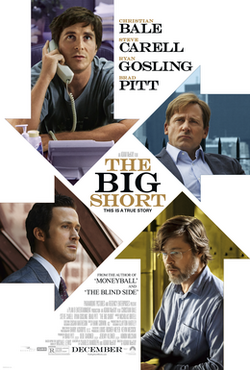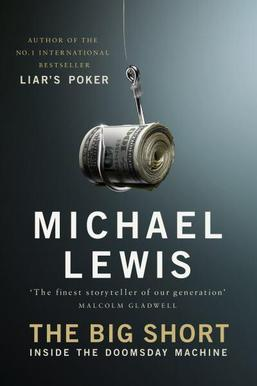

## **The Undoing Project: A Friendship that Changed the Worl**

El siguiente es un fragmento del libro.

<br>

---


Al principio [Danny y Amos], barajaban la idea de Danny: que la gente no era bayesiana, ni bayesiana conservadora, ni estadística de ningún tipo. Lo que fuera que hicieran los seres humanos ante un problema con una respuesta estadísticamente correcta, no era estadística. Pero, ¿cómo convencer a un público de científicos sociales profesionales, más o menos cegados por la teoría? ¿Y cómo ponerlo a prueba?. Decidieron,  inventar una prueba estadística inusual y aplicársela a los científicos para ver cómo les iba. Su argumento se basaría en pruebas que consistían exclusivamente en respuestas a preguntas que les harían a un público determinado; en este caso, un público formado en estadística y teoría de la probabilidad. Danny ideó la mayoría de las preguntas, muchas de las cuales eran versiones sofisticadas de las preguntas sobre fichas de póker rojas y blancas.

A finales del verano de 1969, Amos llevó el cuestionario de Danny a la reunión anual de la *American Psychological Association* en Washington, D.C., y posteriormente a una conferencia de psicólogos matemáticos. Allí aplicó la prueba a un grupo numeroso de profesionistas con un dominio avanzado de  estadística. Dos de los participantes habían escrito libros de texto de estadística. Amos recogió las respuestas completadas y voló con ellas de regreso a Jerusalén.
Allí, él y Danny se sentaron a escribir juntos por primera vez. Sus oficinas eran diminutas, así que trabajaron en una pequeña sala de seminarios. Amos no sabía mecanografiar y Danny no tenía mucho interés, así que se sentaron con cuadernos. Repasaron cada frase una y otra vez y escribieron, como mucho, uno o dos párrafos al día. «Tuve una revelación: esto no va a ser lo de siempre, va a ser algo diferente», dijo Danny. «Porque era divertido».
El artículo final rebosaba la seguridad de Amos, empezando por el título que él propuso: **«La confianza en la ley de los números pequeños»** *(Belief in the Law of Small Number)*. Sin embargo, la colaboración fue tan completa que ninguno de los dos se sentía cómodo atribuyéndose el mérito como autor principal; para decidir qué nombre aparecería primero, lanzaron una moneda al aire. Amos Ganó.

Incluso las personas con formación en estadística y teoría de la probabilidad no lograron intuir hasta qué punto una muestra pequeña podía ser mucho más variable que la población general, y que cuanto menor fuera la muestra, menor sería la probabilidad de que reflejara a la población en general."


- Michael Lewis en **"The Undoing Project", chap. 5 The collision**.





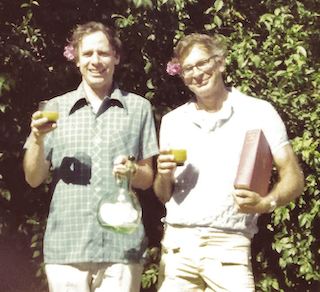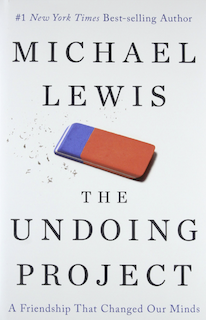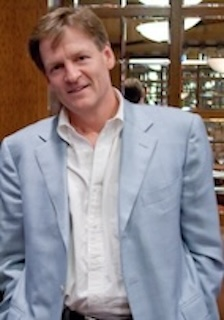

## **Tarea:**

<br>


Realiza los siguientes ejercicios del **Chap. 4:**

* 4.1, 4.2, 4.3, 4.5, 4.9.
* Ejercicios en computadora:
    * C4.1, C4.3, C4.5, C4.6, C4.7
